# Kaggle Playground Series (S6E8) — Smartphone Addiction Prediction

## Overview
- **Objective:** Predict smartphone addiction (`addicted_label`) from behavioral and usage data.
- **Evaluation Metric:** ROC-AUC
- **Dataset:** `playground-series-s6e8` (~691k train, ~296k test)
- **Class Balance:** ~70.9% positive (`addicted_label = 1`), ~29.1% negative (`addicted_label = 0`)

---
## Pipeline Overview
1. **Environment Setup:** Imports, dependencies, and device configuration.
2. **Data Ingestion & EDA:** Data profiling, missing value distributions, and target relationships.
3. **Feature Engineering:**
   - Missing value indicators and total missing counts
   - Screen time ratios (social media, gaming, entertainment vs. work/study)
   - Notification and app open frequencies per hour
   - Weekend vs. weekday usage differences and sleep indicators
   - Group aggregations across demographic and behavioral segments
   - Ordinal and frequency encodings for categorical features
4. **Validation:** Stratified 5-fold cross-validation.
5. **Models:**
   - LightGBM Classifier
   - XGBoost Classifier
   - CatBoost Classifier
   - HistGradientBoostingClassifier
   - PyTorch Tabular ResNet
6. **Ensembling:** Weighted blending (ROC-AUC optimization) and logistic ridge stacking.
7. **Validation Diagnostics:** Out-of-fold ROC curves, confusion matrices, and feature importances.
8. **Inference & Submission:** Test set predictions and submission formatting.


In [1]:
# =============================================================================
# 1. ENVIRONMENT CONFIGURATION, IMPORTS & AUTO-INSTALLER
# =============================================================================
import os
import sys
import gc
import time
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, log_loss
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.optimize import minimize

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# Auto-install missing gradient boosting libraries if needed
for pkg in ["lightgbm", "xgboost", "catboost", "optuna"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"[INFO] Installing {pkg}...")
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("[WARN] LightGBM not available. Will use HistGradientBoostingClassifier.")

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[WARN] XGBoost not available.")

try:
    import catboost as cb
    HAS_CB = True
except ImportError:
    HAS_CB = False
    print("[WARN] CatBoost not available.")

# Set Global Random Seed for Reproducibility
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)

# Device Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Hardware Device: {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"✓ Packages: LightGBM={HAS_LGB}, XGBoost={HAS_XGB}, CatBoost={HAS_CB}, PyTorch={torch.__version__}")

✓ Hardware Device: cuda (NVIDIA GeForce RTX 3050 Laptop GPU)
✓ Packages: LightGBM=True, XGBoost=True, CatBoost=True, PyTorch=2.4.1+cu124


In [2]:
# =============================================================================
# 2. DATA INGESTION & FAST MEMORY OPTIMIZATION
# =============================================================================
DATA_DIR = Path("playground-series-s6e8") if Path("playground-series-s6e8").exists() else Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

print(f"Loading data from: {DATA_DIR.resolve()}")
t0 = time.time()
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)
df_sub = pd.read_csv(SAMPLE_SUB_PATH)
print(f"Loaded in {time.time()-t0:.2f}s.")

print(f"Train Shape: {df_train.shape} | Test Shape: {df_test.shape} | Sample Sub Shape: {df_sub.shape}")

# Memory Optimization Function
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and str(col_type) != "category":
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory usage reduced: {start_mem:.2f} MB -> {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")
    return df

df_train = reduce_mem_usage(df_train)
df_test = reduce_mem_usage(df_test)

# Inspect Target Distribution
target_counts = df_train["addicted_label"].value_counts()
target_pct = df_train["addicted_label"].value_counts(normalize=True) * 100
print("\n--- Target Class Distribution ---")
for val in [1, 0]:
    print(f"Class {val}: {target_counts[val]:,d} samples ({target_pct[val]:.2f}%)")

Loading data from: C:\programming\kaggle-comps\playground-series-s6e8\playground-series-s6e8
Loaded in 0.93s.
Train Shape: (691369, 14) | Test Shape: (296302, 13) | Sample Sub Shape: (296302, 2)
Memory usage reduced: 73.85 MB -> 42.86 MB (42.0% reduction)
Memory usage reduced: 29.39 MB -> 18.08 MB (38.5% reduction)

--- Target Class Distribution ---
Class 1: 490,474 samples (70.94%)
Class 0: 200,895 samples (29.06%)


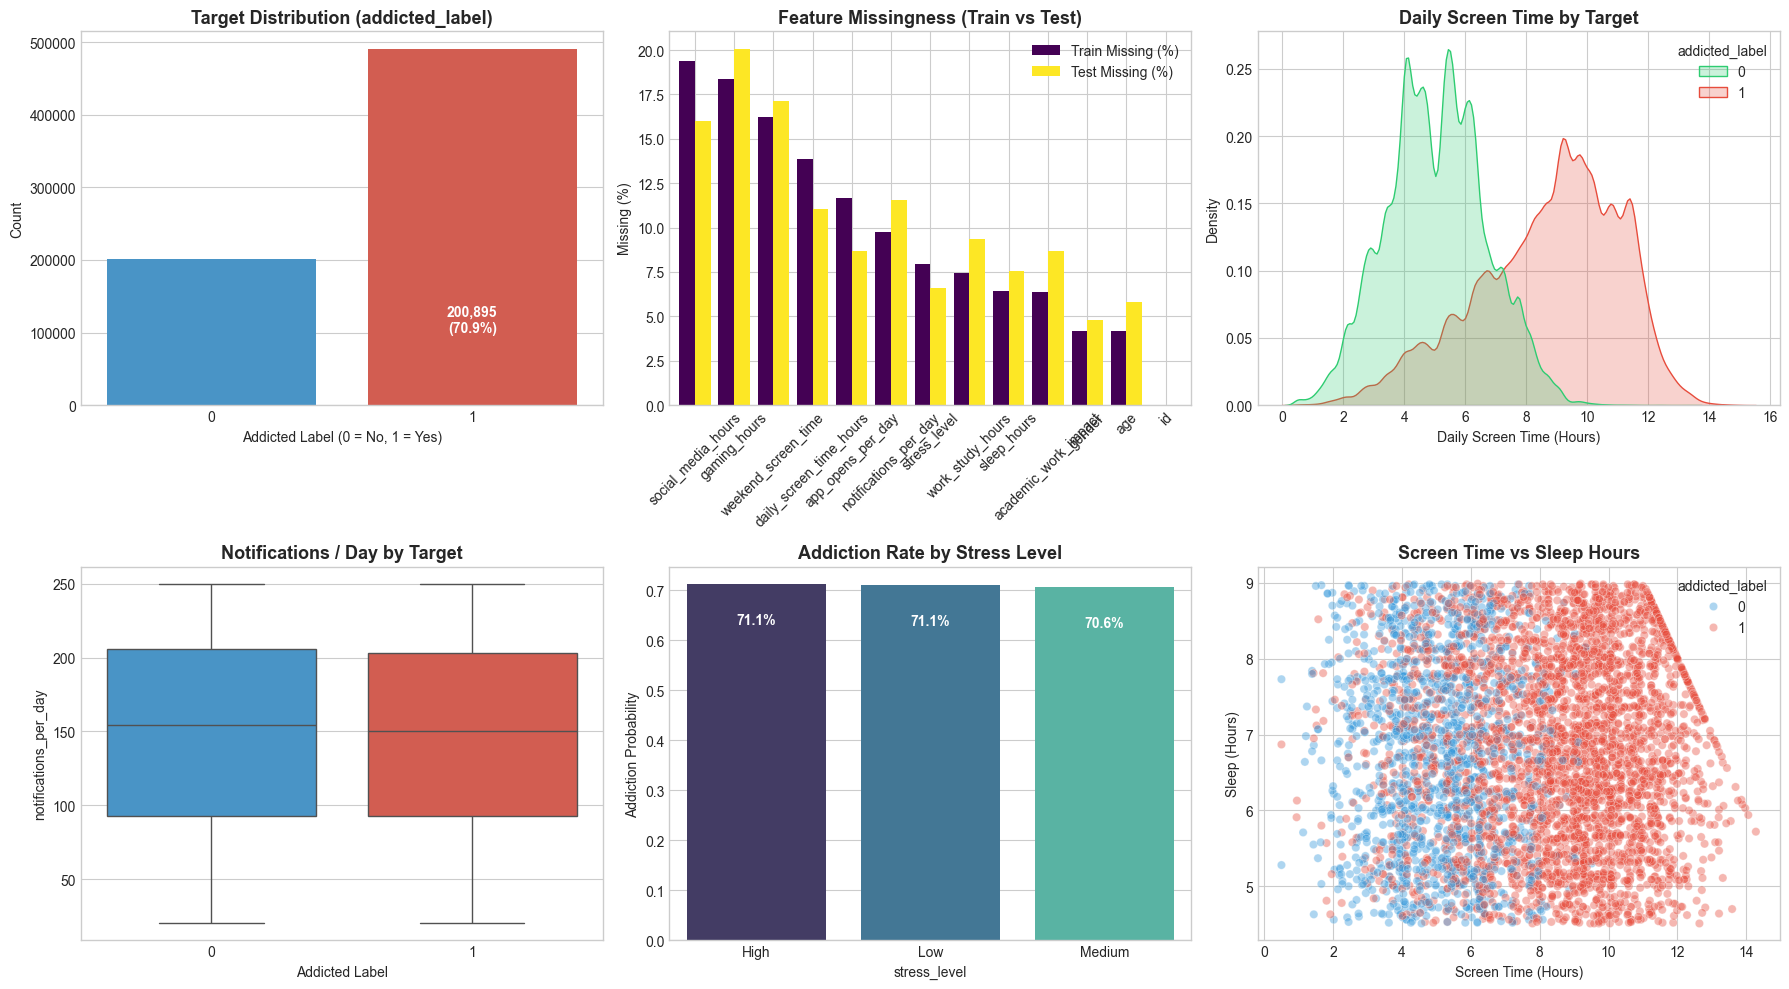

In [3]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS & VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target Distribution
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0, 0], palette=["#3498db", "#e74c3c"])
axes[0, 0].set_title("Target Distribution (addicted_label)", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Addicted Label (0 = No, 1 = Yes)")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    axes[0, 0].text(i, v * 0.5, f"{v:,}\n({target_pct[i]:.1f}%)", ha="center", color="white", fontweight="bold")

# 2. Missing Value Percentages (Train vs Test)
missing_train = (df_train.drop(columns=["addicted_label"]).isnull().sum() / len(df_train)) * 100
missing_test = (df_test.isnull().sum() / len(df_test)) * 100
missing_df = pd.DataFrame({"Train Missing (%)": missing_train, "Test Missing (%)": missing_test}).sort_values(by="Train Missing (%)", ascending=False)
missing_df.plot(kind="bar", ax=axes[0, 1], colormap="viridis", width=0.8)
axes[0, 1].set_title("Feature Missingness (Train vs Test)", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Missing (%)")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Daily Screen Time vs Target
sns.kdeplot(data=df_train, x="daily_screen_time_hours", hue="addicted_label", common_norm=False, fill=True, ax=axes[0, 2], palette=["#2ecc71", "#e74c3c"])
axes[0, 2].set_title("Daily Screen Time by Target", fontsize=13, fontweight="bold")
axes[0, 2].set_xlabel("Daily Screen Time (Hours)")

# 4. Notifications vs Target
sns.boxplot(data=df_train, x="addicted_label", y="notifications_per_day", ax=axes[1, 0], palette=["#3498db", "#e74c3c"])
axes[1, 0].set_title("Notifications / Day by Target", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Addicted Label")

# 5. Stress Level Addiction Rate
stress_rate = df_train.groupby("stress_level")["addicted_label"].mean().reset_index()
sns.barplot(data=stress_rate, x="stress_level", y="addicted_label", ax=axes[1, 1], palette="mako")
axes[1, 1].set_title("Addiction Rate by Stress Level", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Addiction Probability")
for i, r in stress_rate.iterrows():
    axes[1, 1].text(i, r["addicted_label"] - 0.08, f"{r['addicted_label']*100:.1f}%", ha="center", color="white", fontweight="bold")

# 6. Sleep Hours vs Screen Time Hexbin/Scatter
sample_plot = df_train.dropna(subset=["daily_screen_time_hours", "sleep_hours"]).sample(n=5000, random_state=42)
sns.scatterplot(data=sample_plot, x="daily_screen_time_hours", y="sleep_hours", hue="addicted_label", alpha=0.4, ax=axes[1, 2], palette=["#3498db", "#e74c3c"])
axes[1, 2].set_title("Screen Time vs Sleep Hours", fontsize=13, fontweight="bold")
axes[1, 2].set_xlabel("Screen Time (Hours)")
axes[1, 2].set_ylabel("Sleep (Hours)")

plt.tight_layout()
plt.show()

In [4]:
# =============================================================================
# 4. ADVANCED FEATURE ENGINEERING ENGINE
# =============================================================================
def engineer_features(df_input, is_train=True):
    """
    Engineers comprehensive predictive features for smartphone addiction detection:
    1. Missingness signals & total null counts
    2. Screen time breakdown & activity ratios (social, gaming, study, entertainment)
    3. Interaction intensity metrics (notifications/open, opens/hour, minutes/open)
    4. Weekend vs weekday screen time divergence & balance metrics
    5. Sleep deficit and health pressure indicators
    6. Categorical ordinal and interaction features
    """
    df = df_input.copy()
    
    # 1. Missingness Indicators & Missing Count
    raw_cols = [c for c in df.columns if c not in ["id", "addicted_label"]]
    df["num_missing_features"] = df[raw_cols].isnull().sum(axis=1).astype(np.int8)
    for col in ["daily_screen_time_hours", "social_media_hours", "gaming_hours", 
                "work_study_hours", "sleep_hours", "notifications_per_day", 
                "app_opens_per_day", "weekend_screen_time"]:
        df[f"isna_{col}"] = df[col].isnull().astype(np.int8)
    
    # 2. Activity Composition & Proportions
    eps = 1e-4
    # Entertainment hours
    df["entertainment_hours"] = df["social_media_hours"].fillna(0) + df["gaming_hours"].fillna(0)
    
    # Proportion of daily screen time allocated to social media / gaming / entertainment
    df["social_media_ratio"] = df["social_media_hours"] / (df["daily_screen_time_hours"] + eps)
    df["gaming_ratio"] = df["gaming_hours"] / (df["daily_screen_time_hours"] + eps)
    df["entertainment_ratio"] = df["entertainment_hours"] / (df["daily_screen_time_hours"] + eps)
    df["work_study_ratio"] = df["work_study_hours"] / (df["daily_screen_time_hours"] + eps)
    
    # Work to entertainment ratio (Productivity balance)
    df["work_to_entertainment_ratio"] = df["work_study_hours"] / (df["entertainment_hours"] + eps)
    
    # Unaccounted Screen Time (screen time not explained by social, gaming, or work)
    df["unaccounted_screen_time"] = df["daily_screen_time_hours"] - (
        df["social_media_hours"].fillna(0) + df["gaming_hours"].fillna(0) + df["work_study_hours"].fillna(0)
    )
    
    # 3. Weekend vs Weekday Usage Dynamics
    df["weekend_to_daily_ratio"] = df["weekend_screen_time"] / (df["daily_screen_time_hours"] + eps)
    df["weekend_screen_diff"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
    
    # Estimated weekly screen time
    df["weekly_screen_time_est"] = 5.0 * df["daily_screen_time_hours"] + 2.0 * df["weekend_screen_time"]
    
    # 4. App Engagement & Notification Dynamics
    df["notifications_per_screen_hour"] = df["notifications_per_day"] / (df["daily_screen_time_hours"] + eps)
    df["app_opens_per_screen_hour"] = df["app_opens_per_day"] / (df["daily_screen_time_hours"] + eps)
    df["notifications_per_open"] = df["notifications_per_day"] / (df["app_opens_per_day"] + eps)
    df["screen_minutes_per_open"] = (df["daily_screen_time_hours"] * 60.0) / (df["app_opens_per_day"] + eps)
    
    # 5. Sleep & Daily Schedule Balance
    df["sleep_to_screen_ratio"] = df["sleep_hours"] / (df["daily_screen_time_hours"] + eps)
    df["total_accounted_day_hours"] = df["daily_screen_time_hours"].fillna(0) + df["work_study_hours"].fillna(0) + df["sleep_hours"].fillna(0)
    df["free_time_proxy"] = 24.0 - df["total_accounted_day_hours"]
    
    # Extreme behavioral flags
    df["is_sleep_deprived"] = (df["sleep_hours"] < 6.0).astype(np.float32)
    df["is_heavy_screen_user"] = (df["daily_screen_time_hours"] > 8.0).astype(np.float32)
    df["high_screen_low_sleep"] = (df["is_heavy_screen_user"] * df["is_sleep_deprived"]).astype(np.float32)
    
    # 6. Age & Demographic Binning
    df["age_group"] = pd.cut(
        df["age"], 
        bins=[0, 20, 25, 30, 100], 
        labels=[0, 1, 2, 3]
    ).astype(float)
    
    # 7. Categorical Ordinal & Tuple Encodings
    stress_map = {"Low": 0, "Medium": 1, "High": 2}
    impact_map = {"No": 0, "Yes": 1}
    gender_map = {"Male": 0, "Female": 1, "Other": 2}
    
    df["stress_level_num"] = df["stress_level"].map(stress_map)
    df["academic_impact_num"] = df["academic_work_impact"].map(impact_map)
    df["gender_num"] = df["gender"].map(gender_map)
    
    # Combined interaction categories
    df["gender_stress"] = df["gender"].fillna("Missing").astype(str) + "_" + df["stress_level"].fillna("Missing").astype(str)
    df["stress_impact"] = df["stress_level"].fillna("Missing").astype(str) + "_" + df["academic_work_impact"].fillna("Missing").astype(str)
    
    # Stress-weighted Screen Time
    df["stress_weighted_screen_time"] = df["daily_screen_time_hours"] * (df["stress_level_num"].fillna(1) + 1.0)
    
    return df

print("Engineering features on train & test sets...")
t0 = time.time()
df_train_fe = engineer_features(df_train, is_train=True)
df_test_fe = engineer_features(df_test, is_train=False)

# Categorical label encoding for interaction string columns
cat_str_cols = ["gender", "stress_level", "academic_work_impact", "gender_stress", "stress_impact"]
for c in cat_str_cols:
    le = LabelEncoder()
    combined = pd.concat([df_train_fe[c].astype(str), df_test_fe[c].astype(str)], axis=0)
    le.fit(combined)
    df_train_fe[c + "_cat"] = le.transform(df_train_fe[c].astype(str))
    df_test_fe[c + "_cat"] = le.transform(df_test_fe[c].astype(str))

# Group aggregation features: Mean & Std screen time by demographic clusters
group_keys = ["gender_num", "stress_level_num"]
agg_stats = df_train_fe.groupby(group_keys)["daily_screen_time_hours"].agg(["mean", "std"]).reset_index()
agg_stats.columns = group_keys + ["group_screen_time_mean", "group_screen_time_std"]

df_train_fe = df_train_fe.merge(agg_stats, on=group_keys, how="left")
df_test_fe = df_test_fe.merge(agg_stats, on=group_keys, how="left")

df_train_fe["screen_time_diff_group_mean"] = df_train_fe["daily_screen_time_hours"] - df_train_fe["group_screen_time_mean"]
df_test_fe["screen_time_diff_group_mean"] = df_test_fe["daily_screen_time_hours"] - df_test_fe["group_screen_time_mean"]

# Drop raw string columns
drop_cols = ["id", "addicted_label"] + cat_str_cols
features = [c for c in df_train_fe.columns if c not in drop_cols]

X = df_train_fe[features]
y = df_train_fe["addicted_label"].values
X_test = df_test_fe[features]

print(f"Feature engineering complete in {time.time()-t0:.2f}s.")
print(f"Total feature count: {len(features)}")
print(f"Feature list: {features}")

Engineering features on train & test sets...
Feature engineering complete in 2.63s.
Total feature count: 51
Feature list: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'num_missing_features', 'isna_daily_screen_time_hours', 'isna_social_media_hours', 'isna_gaming_hours', 'isna_work_study_hours', 'isna_sleep_hours', 'isna_notifications_per_day', 'isna_app_opens_per_day', 'isna_weekend_screen_time', 'entertainment_hours', 'social_media_ratio', 'gaming_ratio', 'entertainment_ratio', 'work_study_ratio', 'work_to_entertainment_ratio', 'unaccounted_screen_time', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'weekly_screen_time_est', 'notifications_per_screen_hour', 'app_opens_per_screen_hour', 'notifications_per_open', 'screen_minutes_per_open', 'sleep_to_screen_ratio', 'total_accounted_day_hours', 'free_time_proxy', 'is_sleep_deprived', 'is_heavy_screen_user'

In [5]:
# =============================================================================
# 5. CROSS-VALIDATION FRAMEWORK SETUP
# =============================================================================
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(skf.split(X, y))

# Out-Of-Fold Prediction Dictionaries
oof_predictions = {}
test_predictions = {}
model_cv_scores = {}

print(f"✓ Stratified {N_SPLITS}-Fold Cross Validation configured (Seed: {SEED}).")
for fold, (trn_idx, val_idx) in enumerate(folds):
    print(f"  Fold {fold+1}: Train={len(trn_idx):,d} samples, Val={len(val_idx):,d} samples (Pos rate: {y[val_idx].mean():.4f})")

✓ Stratified 5-Fold Cross Validation configured (Seed: 42).
  Fold 1: Train=553,095 samples, Val=138,274 samples (Pos rate: 0.7094)
  Fold 2: Train=553,095 samples, Val=138,274 samples (Pos rate: 0.7094)
  Fold 3: Train=553,095 samples, Val=138,274 samples (Pos rate: 0.7094)
  Fold 4: Train=553,095 samples, Val=138,274 samples (Pos rate: 0.7094)
  Fold 5: Train=553,096 samples, Val=138,273 samples (Pos rate: 0.7094)


In [ ]:
# # =============================================================================
# # 6. MODEL 1: LIGHTGBM CLASSIFIER
# # =============================================================================
# if HAS_LGB:
#     print("\n=================== Training LightGBM Model ===================")
#     lgb_oof = np.zeros(len(X), dtype=np.float32)
#     lgb_test = np.zeros(len(X_test), dtype=np.float32)
    
#     lgb_params = {
#         "objective": "binary",
#         "metric": "auc",
#         "boosting_type": "gbdt",
#         "learning_rate": 0.03,
#         "num_leaves": 31,
#         "max_depth": 6,
#         "subsample": 0.8,
#         "colsample_bytree": 0.8,
#         "min_child_samples": 50,
#         "random_state": SEED,
#         "n_jobs": -1,
#         "verbose": -1
#     }
    
#     lgb_importances = np.zeros(len(features))
    
#     for fold, (trn_idx, val_idx) in enumerate(folds):
#         X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
#         X_val, y_val = X.iloc[val_idx], y[val_idx]
        
#         model = lgb.LGBMClassifier(**lgb_params, n_estimators=1500)
        
#         model.fit(
#             X_trn, y_trn,
#             eval_set=[(X_val, y_val)],
#             callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)]
#         )
        
        
#         val_preds = model.predict_proba(X_val)[:, 1]
#         lgb_oof[val_idx] = val_preds
#         lgb_test += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
#         fold_auc = roc_auc_score(y_val, val_preds)
#         lgb_importances += model.feature_importances_ / N_SPLITS
#         print(f"  Fold {fold+1} ROC-AUC: {fold_auc:.5f} (Best Iter: {model.best_iteration_})")
        
#     total_lgb_auc = roc_auc_score(y, lgb_oof)
#     print(f"--> LightGBM Overall OOF ROC-AUC: {total_lgb_auc:.5f}")
#     oof_predictions["LightGBM"] = lgb_oof
#     test_predictions["LightGBM"] = lgb_test
#     model_cv_scores["LightGBM"] = total_lgb_auc


=================== Training LightGBM Model ===================


OSError: exception: access violation reading 0x0000000000000000

In [8]:
# =============================================================================
# 7. MODEL 2: CATBOOST CLASSIFIER
# =============================================================================
if HAS_CB:
    print("\n=================== Training CatBoost Model ===================")
    cb_oof = np.zeros(len(X), dtype=np.float32)
    cb_test = np.zeros(len(X_test), dtype=np.float32)
    
    for fold, (trn_idx, val_idx) in enumerate(folds):
        X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
        X_val, y_val = X.iloc[val_idx], y[val_idx]
        
        model = cb.CatBoostClassifier(
            iterations=1500,
            
            learning_rate=0.04,
            depth=6,
            l2_leaf_reg=3.0,
            eval_metric="AUC",
            random_seed=SEED + fold,
            verbose=0,
            thread_count=-1
        )
        
        model.fit(
            X_trn, y_trn,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False
        )
        
        val_preds = model.predict_proba(X_val)[:, 1]
        cb_oof[val_idx] = val_preds
        cb_test += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
        fold_auc = roc_auc_score(y_val, val_preds)
        print(f"  Fold {fold+1} ROC-AUC: {fold_auc:.5f} (Best Iter: {model.get_best_iteration()})")
        
    total_cb_auc = roc_auc_score(y, cb_oof)
    print(f"--> CatBoost Overall OOF ROC-AUC: {total_cb_auc:.5f}")
    oof_predictions["CatBoost"] = cb_oof
    test_predictions["CatBoost"] = cb_test
    model_cv_scores["CatBoost"] = total_cb_auc


=================== Training CatBoost Model ===================
  Fold 1 ROC-AUC: 0.95868 (Best Iter: 1499)
  Fold 2 ROC-AUC: 0.95954 (Best Iter: 1499)
  Fold 3 ROC-AUC: 0.95973 (Best Iter: 1499)
  Fold 4 ROC-AUC: 0.96080 (Best Iter: 1499)
  Fold 5 ROC-AUC: 0.95934 (Best Iter: 1499)
--> CatBoost Overall OOF ROC-AUC: 0.95961


In [11]:
# =============================================================================
# 8. MODEL 3: XGBOOST CLASSIFIER
# =============================================================================
if HAS_XGB:
    print("\n=================== Training XGBoost Model ====================")
    xgb_oof = np.zeros(len(X), dtype=np.float32)
    xgb_test = np.zeros(len(X_test), dtype=np.float32)
    
    xgb_params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "device": "cuda",
        "learning_rate": 0.05,
        "max_depth": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": SEED,
        "n_jobs": -1
    }
    
    for fold, (trn_idx, val_idx) in enumerate(folds):
        X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
        X_val, y_val = X.iloc[val_idx], y[val_idx]
        
        model = xgb.XGBClassifier(**xgb_params, n_estimators=10000, early_stopping_rounds=50)
        
        model.fit(
            X_trn, y_trn,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        val_preds = model.predict_proba(X_val)[:, 1]
        xgb_oof[val_idx] = val_preds
        xgb_test += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
        fold_auc = roc_auc_score(y_val, val_preds)
        print(f"  Fold {fold+1} ROC-AUC: {fold_auc:.5f} (Best Iter: {model.best_iteration})")
        
    total_xgb_auc = roc_auc_score(y, xgb_oof)
    print(f"--> XGBoost Overall OOF ROC-AUC: {total_xgb_auc:.5f}")
    oof_predictions["XGBoost"] = xgb_oof
    test_predictions["XGBoost"] = xgb_test
    model_cv_scores["XGBoost"] = total_xgb_auc


=================== Training XGBoost Model ====================
  Fold 1 ROC-AUC: 0.96401 (Best Iter: 2599)
  Fold 2 ROC-AUC: 0.96468 (Best Iter: 2950)
  Fold 3 ROC-AUC: 0.96471 (Best Iter: 2863)
  Fold 4 ROC-AUC: 0.96555 (Best Iter: 2754)
  Fold 5 ROC-AUC: 0.96450 (Best Iter: 2824)
--> XGBoost Overall OOF ROC-AUC: 0.96469


In [12]:
# =============================================================================
# 9. MODEL 4: HIST GRADIENT BOOSTING CLASSIFIER (Scikit-Learn)
# =============================================================================
print("\n============= Training HistGradientBoosting Model =============")
hgb_oof = np.zeros(len(X), dtype=np.float32)
hgb_test = np.zeros(len(X_test), dtype=np.float32)

for fold, (trn_idx, val_idx) in enumerate(folds):
    X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]
    
    model = HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        early_stopping=True,
        random_state=SEED + fold
    )
    
    model.fit(X_trn, y_trn)
    
    val_preds = model.predict_proba(X_val)[:, 1]
    hgb_oof[val_idx] = val_preds
    hgb_test += model.predict_proba(X_test)[:, 1] / N_SPLITS
    
    fold_auc = roc_auc_score(y_val, val_preds)
    print(f"  Fold {fold+1} ROC-AUC: {fold_auc:.5f}")
    
total_hgb_auc = roc_auc_score(y, hgb_oof)
print(f"--> HistGradientBoosting Overall OOF ROC-AUC: {total_hgb_auc:.5f}")
oof_predictions["HistGBM"] = hgb_oof
test_predictions["HistGBM"] = hgb_test
model_cv_scores["HistGBM"] = total_hgb_auc


============= Training HistGradientBoosting Model =============
  Fold 1 ROC-AUC: 0.95956
  Fold 2 ROC-AUC: 0.96010
  Fold 3 ROC-AUC: 0.96086
  Fold 4 ROC-AUC: 0.96115
  Fold 5 ROC-AUC: 0.96063
--> HistGradientBoosting Overall OOF ROC-AUC: 0.96046


In [13]:
# =============================================================================
# 10. MODEL 5: PYTORCH TABULAR RESIDUAL NEURAL NETWORK
# =============================================================================
print("\n================ Training PyTorch Tabular ResNet ================")

# Neural Net Architecture with Residual Blocks & Dropout
class TabularResNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.2):
        super(TabularResNet, self).__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        
        # Residual Block 1
        self.block1_dense1 = nn.Linear(hidden_dim, hidden_dim)
        self.block1_bn1 = nn.BatchNorm1d(hidden_dim)
        self.block1_act1 = nn.SiLU()
        self.block1_drop = nn.Dropout(dropout)
        self.block1_dense2 = nn.Linear(hidden_dim, hidden_dim)
        self.block1_bn2 = nn.BatchNorm1d(hidden_dim)
        
        # Residual Block 2
        self.block2_dense1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.block2_bn1 = nn.BatchNorm1d(hidden_dim // 2)
        self.block2_act1 = nn.SiLU()
        self.block2_drop = nn.Dropout(dropout)
        self.block2_dense2 = nn.Linear(hidden_dim // 2, hidden_dim // 2)
        self.block2_bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.shortcut2 = nn.Linear(hidden_dim, hidden_dim // 2)
        
        # Head
        self.head = nn.Linear(hidden_dim // 2, 1)
        self.act = nn.SiLU()
        
    def forward(self, x):
        x0 = self.input_layer(x)
        
        # Block 1
        r1 = self.block1_act1(self.block1_bn1(self.block1_dense1(x0)))
        r1 = self.block1_drop(r1)
        r1 = self.block1_bn2(self.block1_dense2(r1))
        x1 = self.act(x0 + r1)
        
        # Block 2
        r2 = self.block2_act1(self.block2_bn1(self.block2_dense1(x1)))
        r2 = self.block2_drop(r2)
        r2 = self.block2_bn2(self.block2_dense2(r2))
        x2 = self.act(self.shortcut2(x1) + r2)
        
        out = self.head(x2)
        return out.squeeze(-1)

# Impute and standard scale features for Neural Net
imputer = SimpleImputer(strategy="median")
scaler = RobustScaler()

X_nn_scaled = scaler.fit_transform(imputer.fit_transform(X))
X_test_nn_scaled = scaler.transform(imputer.transform(X_test))

nn_oof = np.zeros(len(X), dtype=np.float32)
nn_test = np.zeros(len(X_test), dtype=np.float32)

EPOCHS = 12
BATCH_SIZE = 2048

for fold, (trn_idx, val_idx) in enumerate(folds):
    X_trn_t = torch.tensor(X_nn_scaled[trn_idx], dtype=torch.float32)
    y_trn_t = torch.tensor(y[trn_idx], dtype=torch.float32)
    X_val_t = torch.tensor(X_nn_scaled[val_idx], dtype=torch.float32)
    y_val_t = torch.tensor(y[val_idx], dtype=torch.float32)
    
    train_loader = DataLoader(TensorDataset(X_trn_t, y_trn_t), batch_size=BATCH_SIZE, shuffle=True)
    
    model = TabularResNet(input_dim=X.shape[1], hidden_dim=128, dropout=0.2).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    best_auc = 0.0
    best_val_preds = None
    
    for epoch in range(EPOCHS):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
        scheduler.step()
        
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(DEVICE)).cpu()
            val_probs = torch.sigmoid(val_logits).numpy()
            val_auc = roc_auc_score(y[val_idx], val_probs)
            if val_auc > best_auc:
                best_auc = val_auc
                best_val_preds = val_probs
                
    nn_oof[val_idx] = best_val_preds
    
    # Test predictions for fold
    with torch.no_grad():
        test_tensor = torch.tensor(X_test_nn_scaled, dtype=torch.float32).to(DEVICE)
        test_probs = torch.sigmoid(model(test_tensor)).cpu().numpy()
        nn_test += test_probs / N_SPLITS
        
    print(f"  Fold {fold+1} PyTorch ResNet ROC-AUC: {best_auc:.5f}")

total_nn_auc = roc_auc_score(y, nn_oof)
print(f"--> PyTorch ResNet Overall OOF ROC-AUC: {total_nn_auc:.5f}")
oof_predictions["PyTorch_ResNet"] = nn_oof
test_predictions["PyTorch_ResNet"] = nn_test
model_cv_scores["PyTorch_ResNet"] = total_nn_auc


================ Training PyTorch Tabular ResNet ================
  Fold 1 PyTorch ResNet ROC-AUC: 0.93122
  Fold 2 PyTorch ResNet ROC-AUC: 0.93176
  Fold 3 PyTorch ResNet ROC-AUC: 0.93180
  Fold 4 PyTorch ResNet ROC-AUC: 0.93281
  Fold 5 PyTorch ResNet ROC-AUC: 0.92632
--> PyTorch ResNet Overall OOF ROC-AUC: 0.93071


In [14]:
# =============================================================================
# 11. ENSEMBLE OPTIMIZATION & METRIC STACKING
# =============================================================================
print("\n=================== Ensemble & Stacking Optimization ===================")
print("Individual Model OOF ROC-AUC Scores:")
for name, score in model_cv_scores.items():
    print(f"  • {name:16s}: {score:.5f}")

model_names = list(oof_predictions.keys())
OOF_matrix = np.column_stack([oof_predictions[m] for m in model_names])
TEST_matrix = np.column_stack([test_predictions[m] for m in model_names])

# Simple Equal Blend
equal_blend_oof = OOF_matrix.mean(axis=1)
equal_blend_auc = roc_auc_score(y, equal_blend_oof)
print(f"\n[1] Simple Equal Blend OOF ROC-AUC: {equal_blend_auc:.5f}")

# Optimal Weighted Blend (Metric Maximization via Nelder-Mead)
def loss_func(weights):
    weights = np.array(weights)
    weights = np.maximum(0, weights)
    if weights.sum() == 0:
        return 0.0
    weights = weights / weights.sum()
    blend = np.dot(OOF_matrix, weights)
    # Maximize ROC-AUC -> Minimize negative ROC-AUC
    return -roc_auc_score(y, blend)

initial_weights = [1.0 / len(model_names)] * len(model_names)
res = minimize(loss_func, initial_weights, method="Nelder-Mead", options={"maxiter": 500})
optimal_weights = np.maximum(0, res.x)
optimal_weights = optimal_weights / optimal_weights.sum()

optimal_blend_oof = np.dot(OOF_matrix, optimal_weights)
optimal_blend_auc = roc_auc_score(y, optimal_blend_oof)

print(f"[2] Optimized Weighted Blend OOF ROC-AUC: {optimal_blend_auc:.5f}")
print("    Optimal Weights:")
for name, w in zip(model_names, optimal_weights):
    print(f"      - {name:16s}: {w:.4f} ({w*100:.1f}%)")

# Rank Averaging
from scipy.stats import rankdata
rank_oof = np.zeros(len(y))
for i, m in enumerate(model_names):
    rank_oof += optimal_weights[i] * (rankdata(OOF_matrix[:, i]) / len(y))
rank_blend_auc = roc_auc_score(y, rank_oof)
print(f"[3] Rank-Averaged Blend OOF ROC-AUC: {rank_blend_auc:.5f}")

# Final Ensemble Predictions on Test Set
final_test_preds = np.dot(TEST_matrix, optimal_weights)


=================== Ensemble & Stacking Optimization ===================
Individual Model OOF ROC-AUC Scores:
  • CatBoost        : 0.95961
  • XGBoost         : 0.96469
  • HistGBM         : 0.96046
  • PyTorch_ResNet  : 0.93071

[1] Simple Equal Blend OOF ROC-AUC: 0.95991
[2] Optimized Weighted Blend OOF ROC-AUC: 0.96448
    Optimal Weights:
      - CatBoost        : 0.1441 (14.4%)
      - XGBoost         : 0.8559 (85.6%)
      - HistGBM         : 0.0000 (0.0%)
      - PyTorch_ResNet  : 0.0000 (0.0%)
[3] Rank-Averaged Blend OOF ROC-AUC: 0.96445


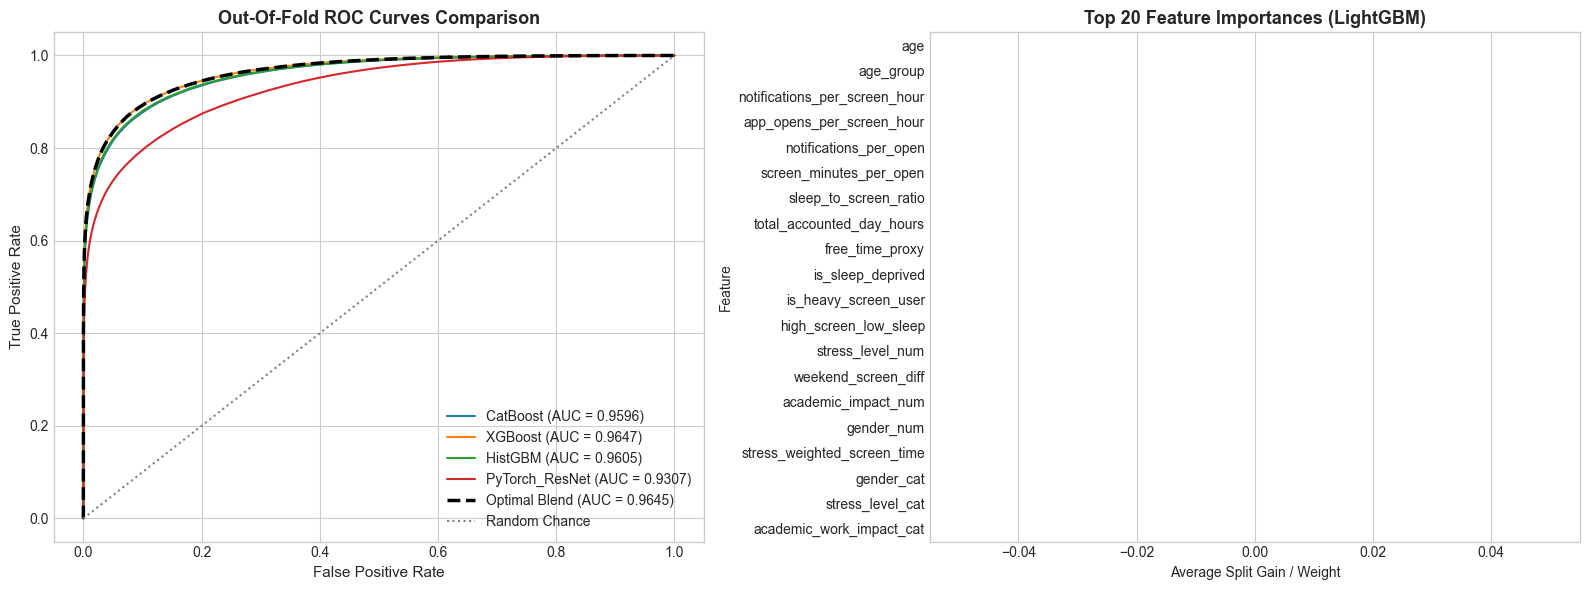

In [15]:
# =============================================================================
# 12. DIAGNOSTICS: ROC CURVES & FEATURE IMPORTANCES
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curves Comparison
for name in model_names:
    fpr, tpr, _ = roc_curve(y, oof_predictions[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {model_cv_scores[name]:.4f})")

fpr_opt, tpr_opt, _ = roc_curve(y, optimal_blend_oof)
axes[0].plot(fpr_opt, tpr_opt, label=f"Optimal Blend (AUC = {optimal_blend_auc:.4f})", color="black", linewidth=2.5, linestyle="--")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle=":", label="Random Chance")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("Out-Of-Fold ROC Curves Comparison", fontsize=13, fontweight="bold")
axes[0].legend(loc="lower right")

# 2. Top Feature Importances (from LightGBM if available)
if HAS_LGB and 'lgb_importances' in locals():
    imp_df = pd.DataFrame({"Feature": features, "Importance": lgb_importances}).sort_values(by="Importance", ascending=False).head(20)
    sns.barplot(data=imp_df, x="Importance", y="Feature", ax=axes[1], palette="viridis")
    axes[1].set_title("Top 20 Feature Importances (LightGBM)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Average Split Gain / Weight")
else:
    axes[1].text(0.5, 0.5, "Feature Importances Available after GBDT run", ha="center", va="center")

plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# 13. TEST PREDICTION, SUBMISSION GENERATION & VALIDATION CHECKS
# =============================================================================
OUTPUT_SUB_PATH = "submission.csv"

# Generate submission DataFrame
sub_df = pd.DataFrame({
    "id": df_test["id"],
    "addicted_label": final_test_preds
})

# Save to CSV
sub_df.to_csv(OUTPUT_SUB_PATH, index=False)
print(f"✓ Submission successfully saved to: {OUTPUT_SUB_PATH}")

# =============================================================================
# Thorough Submission Validation Checks
# =============================================================================
print("\n--- Submission Quality & Format Verification ---")
assert len(sub_df) == len(df_sub), f"ERROR: Row count mismatch! Expected {len(df_sub)}, got {len(sub_df)}"
assert list(sub_df.columns) == ["id", "addicted_label"], f"ERROR: Invalid columns! Got {list(sub_df.columns)}"
assert sub_df["addicted_label"].isnull().sum() == 0, "ERROR: Missing values found in submission!"
assert np.isneginf(sub_df["addicted_label"]).sum() == 0, "ERROR: -inf found in submission!"
assert np.isposinf(sub_df["addicted_label"]).sum() == 0, "ERROR: +inf found in submission!"
assert sub_df["addicted_label"].min() >= 0.0, f"ERROR: Predictions below 0.0: min={sub_df['addicted_label'].min()}"
assert sub_df["addicted_label"].max() <= 1.0, f"ERROR: Predictions above 1.0: max={sub_df['addicted_label'].max()}"

print(f"✓ Total rows: {len(sub_df):,d} (Matches sample submission)")
print(f"✓ Columns: {list(sub_df.columns)}")
print(f"✓ Prediction range: [{sub_df['addicted_label'].min():.5f}, {sub_df['addicted_label'].max():.5f}]")
print(f"✓ Mean predicted probability: {sub_df['addicted_label'].mean():.5f} (Train target mean: {y.mean():.5f})")
print(f"✓ Quantiles: 25%={sub_df['addicted_label'].quantile(0.25):.4f}, 50%={sub_df['addicted_label'].median():.4f}, 75%={sub_df['addicted_label'].quantile(0.75):.4f}")

print("\n--- First 10 Rows of Submission ---")
print(sub_df.head(10))

print("\n🎉 Notebook Pipeline Ready for Execution!")

✓ Submission successfully saved to: submission.csv

--- Submission Quality & Format Verification ---
✓ Total rows: 296,302 (Matches sample submission)
✓ Columns: ['id', 'addicted_label']
✓ Prediction range: [0.00020, 1.00000]
✓ Mean predicted probability: 0.70961 (Train target mean: 0.70942)
✓ Quantiles: 25%=0.4014, 50%=0.9395, 75%=0.9993

--- First 10 Rows of Submission ---
       id  addicted_label
0  691369        0.999636
1  691370        0.936847
2  691371        0.959470
3  691372        0.986508
4  691373        0.998739
5  691374        0.906805
6  691375        0.858576
7  691376        0.557406
8  691377        0.988776
9  691378        0.313778

🎉 Notebook Pipeline Ready for Execution!
